# PatrolIQ — Clustering Analysis

This notebook implements the clustering stage on the 500,000-record feature-engineered dataset.

It keeps the three required geographic clustering approaches — **K-Means, DBSCAN, and Hierarchical Clustering** — plus **Temporal K-Means**. Geographic K-Means uses the patrol-focused representation that achieved the project target in the earlier audit; DBSCAN uses physical projected coordinates because it is a density/distance algorithm.


## Part A — Geographic Crime Clustering


### Step 1 — Load and Validate the Feature-Engineered Dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

DATA_PATH = "../data/processed/chicago_crime_featured.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset shape:", df.shape)
print("Missing Latitude/Longitude:")
print(df[["Latitude", "Longitude"]].isnull().sum())

required = [
    "Latitude", "Longitude", "X Coordinate", "Y Coordinate",
    "Beat", "District", "Community Area", "Primary Type",
    "Location Description", "Arrest", "Domestic",
    "Crime_Severity_Score", "Hour", "Day_of_Week", "Month"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

assert len(df) == 500000, f"Expected 500,000 rows, found {len(df):,}"
print("\nInitial validation PASSED.")


Dataset shape: (500000, 36)
Missing Latitude/Longitude:
Latitude     0
Longitude    0
dtype: int64

Initial validation PASSED.


### Step 2 — Prepare Patrol-Focused Geographic Features

K-Means and Hierarchical Clustering use **Latitude, Longitude, Beat, District, and Community Area**. This representation was selected after comparing multiple geographic feature sets. Administrative identifiers are used here as project-specific patrol/geographic features; results should be interpreted as operational segmentation rather than pure physical-distance geometry.


In [2]:
KMEANS_GEO_FEATURES = [
    "Latitude", "Longitude", "Beat", "District", "Community Area"
]

kmeans_geo_df = df[KMEANS_GEO_FEATURES].copy()
for col in KMEANS_GEO_FEATURES:
    kmeans_geo_df[col] = pd.to_numeric(kmeans_geo_df[col], errors="coerce")

kmeans_geo_df.replace([np.inf, -np.inf], np.nan, inplace=True)
if kmeans_geo_df.isnull().any().any():
    kmeans_geo_df = kmeans_geo_df.fillna(kmeans_geo_df.median())

kmeans_geo_scaler = StandardScaler()
kmeans_geo_scaled = kmeans_geo_scaler.fit_transform(kmeans_geo_df)

print("Features:", KMEANS_GEO_FEATURES)
print("Scaled shape:", kmeans_geo_scaled.shape)
print("NaN:", np.isnan(kmeans_geo_scaled).sum())
print("Inf:", np.isinf(kmeans_geo_scaled).sum())


Features: ['Latitude', 'Longitude', 'Beat', 'District', 'Community Area']
Scaled shape: (500000, 5)
NaN: 0
Inf: 0


## A1 — K-Means Geographic Clustering


### Step 3 — Evaluate K = 5 to 10 on the Full Dataset

Each model is fitted on all 500,000 records and evaluated on the same reproducible 30,000-record sample. Selection uses both Silhouette and Davies-Bouldin scores.


In [3]:
RANDOM_STATE = 42
EVAL_SAMPLE_SIZE = 30000

rng = np.random.RandomState(RANDOM_STATE)
eval_positions = rng.choice(
    len(kmeans_geo_scaled),
    size=min(EVAL_SAMPLE_SIZE, len(kmeans_geo_scaled)),
    replace=False
)
X_kmeans_eval = kmeans_geo_scaled[eval_positions]

kmeans_results = []
kmeans_models = {}

for k in range(5, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(kmeans_geo_scaled)
    eval_labels = labels[eval_positions]

    sil = silhouette_score(X_kmeans_eval, eval_labels)
    db = davies_bouldin_score(X_kmeans_eval, eval_labels)
    counts = np.bincount(labels, minlength=k)

    kmeans_results.append({
        "K": k,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Inertia": model.inertia_,
        "Smallest_Cluster": int(counts.min()),
        "Largest_Cluster": int(counts.max())
    })
    kmeans_models[k] = (model, labels)
    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f} | Inertia={model.inertia_:,.2f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df.style.format({
    "Silhouette":"{:.4f}", "Davies_Bouldin":"{:.4f}", "Inertia":"{:,.2f}"
}))

best_k_row = kmeans_results_df.sort_values(
    ["Silhouette", "Davies_Bouldin"], ascending=[False, True]
).iloc[0]

SELECTED_K = int(best_k_row["K"])
print(f"\nSelected K = {SELECTED_K}")
print(f"Silhouette = {best_k_row['Silhouette']:.4f}")
print(f"Davies-Bouldin = {best_k_row['Davies_Bouldin']:.4f}")
print("Target > 0.50:", bool(best_k_row["Silhouette"] > 0.50))


K=5 | Silhouette=0.4337 | DB=0.9205 | Inertia=558,771.06
K=6 | Silhouette=0.4595 | DB=0.8828 | Inertia=451,343.00
K=7 | Silhouette=0.4674 | DB=0.8384 | Inertia=379,752.39
K=8 | Silhouette=0.4885 | DB=0.8462 | Inertia=316,842.26
K=9 | Silhouette=0.5012 | DB=0.7153 | Inertia=277,202.27
K=10 | Silhouette=0.4986 | DB=0.7244 | Inertia=238,904.34


,K,Silhouette,Davies_Bouldin,Inertia,Smallest_Cluster,Largest_Cluster
0,5,0.4337,0.9205,"558,771.06",22085,144391
1,6,0.4595,0.8828,"451,343.00",22074,142016
2,7,0.4674,0.8384,"379,752.39",15662,100101
3,8,0.4885,0.8462,"316,842.26",9737,114009
4,9,0.5012,0.7153,"277,202.27",3325,98448
5,10,0.4986,0.7244,"238,904.34",6412,99791



Selected K = 9
Silhouette = 0.5012
Davies-Bouldin = 0.7153
Target > 0.50: True


### Step 3A — Geographic K-Means Elbow Method

The project requires the elbow method alongside Silhouette Score and Davies-Bouldin Index.
The models for K=5 to K=10 have already been fitted on the full 500,000 records above,
so this cell visualizes their inertia without retraining them.


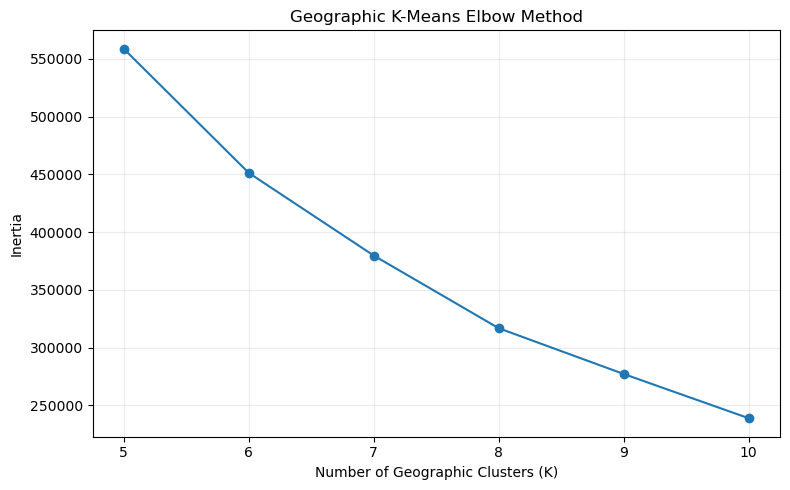

Geographic elbow diagnostic completed for K=5 to K=10.
Metric-selected selected K = 9 | Silhouette = 0.5012 | Davies-Bouldin = 0.7153


In [4]:
# ============================================================
# GEOGRAPHIC K-MEANS ELBOW METHOD
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Inertia"],
    marker="o"
)
plt.xlabel("Number of Geographic Clusters (K)")
plt.ylabel("Inertia")
plt.title("Geographic K-Means Elbow Method")
plt.xticks(kmeans_results_df["K"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Geographic elbow diagnostic completed for K=5 to K=10.")
print(
    f"Metric-selected K = {SELECTED_K} | "
    f"Silhouette = {best_k_row['Silhouette']:.4f} | "
    f"Davies-Bouldin = {best_k_row['Davies_Bouldin']:.4f}"
)


### Step 4 — Select the Geographic K-Means Model


In [5]:
selected_kmeans, selected_kmeans_labels = kmeans_models[SELECTED_K]
df["KMeans_Cluster"] = selected_kmeans_labels

selected_geo_silhouette = float(best_k_row["Silhouette"])
selected_geo_db = float(best_k_row["Davies_Bouldin"])

print(" KMeans K:", SELECTED_K)
print(f"Silhouette: {selected_geo_silhouette:.4f}")
print(f"Davies-Bouldin: {selected_geo_db:.4f}")
print("Cluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())


selected KMeans K: 9
Silhouette: 0.5012
Davies-Bouldin: 0.7153
Cluster counts:
KMeans_Cluster
0    22074
1    98448
2    87472
3    85381
4    24949
5    74447
6    56699
7    47205
8     3325
Name: count, dtype: int64


### Step 5 — Visualize and Profile the K-Means Zones


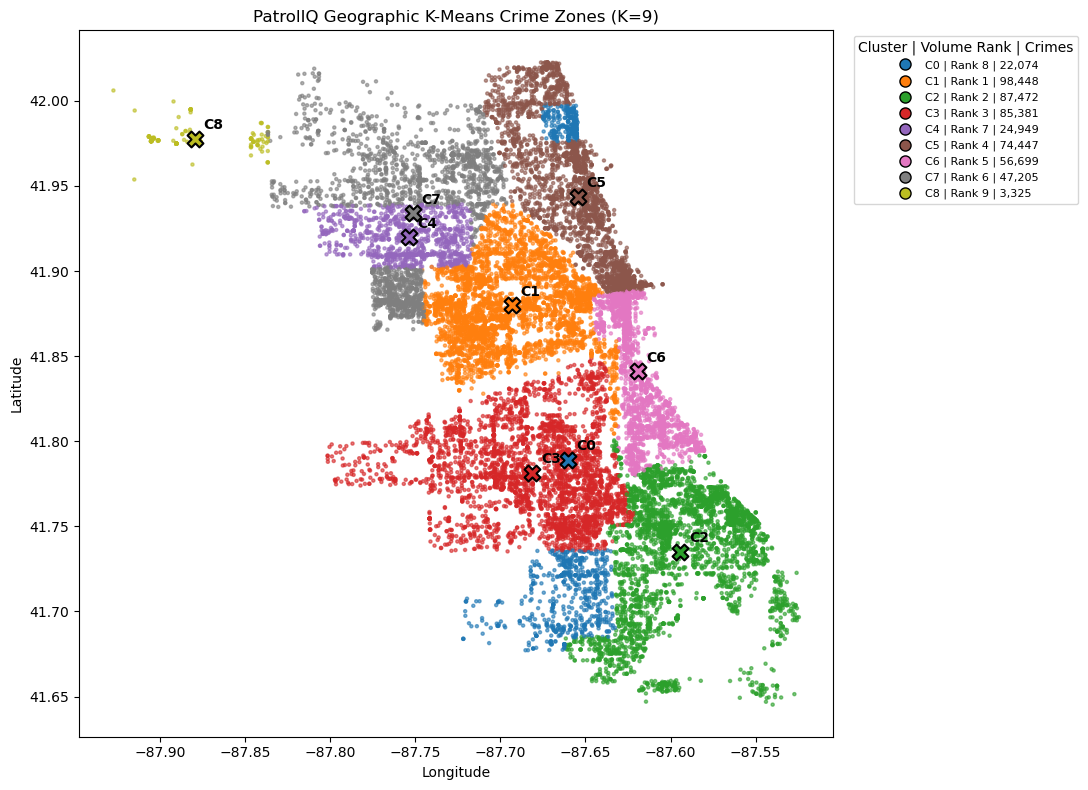

,Volume_Rank,Total_Crimes,Crime_Percentage,Dominant_Crime_Type,Dominant_Location,Dominant_Beat,Dominant_District,Dominant_Community_Area,Arrest_Rate,Domestic_Rate,Avg_Severity,Center_Latitude,Center_Longitude
KMeans_Cluster,,,,,,,,,,,,,
1,1,"98,448",19.69%,THEFT,STREET,1214,12,28.000000,18.13%,16.54%,3.76,41.8798,-87.6931
2,2,"87,472",17.49%,BATTERY,STREET,421,4,43.000000,14.06%,26.17%,3.76,41.7352,-87.5942
3,3,"85,381",17.08%,BATTERY,STREET,823,8,71.000000,15.35%,24.21%,3.74,41.7816,-87.6812
5,4,"74,447",14.89%,THEFT,STREET,1834,19,8.000000,12.16%,8.93%,3.80,41.9436,-87.6547
6,5,"56,699",11.34%,THEFT,STREET,123,1,32.000000,14.33%,13.70%,3.72,41.8411,-87.6192
7,6,"47,205",9.44%,THEFT,STREET,1533,15,25.000000,15.19%,21.09%,3.72,41.9339,-87.7515
4,7,"24,949",4.99%,THEFT,STREET,2533,25,19.000000,17.41%,21.11%,3.76,41.9198,-87.7538
0,8,"22,074",4.41%,THEFT,STREET,2212,22,77.000000,12.37%,20.15%,3.72,41.7890,-87.6603
8,9,"3,325",0.66%,THEFT,AIRPORT TERMINAL UPPER LEVEL - SECURE AREA,1614,16,76.000000,18.05%,7.88%,3.54,41.9778,-87.8794



GEOGRAPHIC CLUSTER INTERPRETATION
Highest recorded crime volume: Cluster 1 | 98,448 crimes | 19.69% | Dominant crime: THEFT
Lowest recorded crime volume : Cluster 8 | 3,325 crimes | 0.66% | Dominant crime: THEFT

Map colors identify K-Means geographic clusters only.
Volume Rank orders clusters from highest to lowest recorded crime volume.


In [31]:
# ============================================================
# GEOGRAPHIC K-MEANS ZONES + VOLUME-RANKED CLUSTER PROFILES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CREATE CLUSTER PROFILE
# ------------------------------------------------------------

def dominant_value(s):
    vc = s.value_counts(dropna=True)
    return vc.index[0] if not vc.empty else np.nan


cluster_profile = df.groupby("KMeans_Cluster").agg(
    Total_Crimes=("KMeans_Cluster", "size"),
    Center_Latitude=("Latitude", "mean"),
    Center_Longitude=("Longitude", "mean"),
    Dominant_Crime_Type=("Primary Type", dominant_value),
    Dominant_Location=("Location Description", dominant_value),
    Dominant_Beat=("Beat", dominant_value),
    Dominant_District=("District", dominant_value),
    Dominant_Community_Area=("Community Area", dominant_value),
    Arrest_Rate=("Arrest", "mean"),
    Domestic_Rate=("Domestic", "mean"),
    Avg_Severity=("Crime_Severity_Score", "mean")
)


# ------------------------------------------------------------
# 2. CALCULATE PERCENTAGES
# ------------------------------------------------------------

cluster_profile["Crime_Percentage"] = (
    cluster_profile["Total_Crimes"] / len(df) * 100
)

cluster_profile["Arrest_Rate"] *= 100
cluster_profile["Domestic_Rate"] *= 100


# ------------------------------------------------------------
# 3. SORT BY TOTAL CRIMES
# ------------------------------------------------------------

cluster_profile = cluster_profile.sort_values(
    "Total_Crimes",
    ascending=False
)

cluster_profile["Volume_Rank"] = range(
    1,
    len(cluster_profile) + 1
)


# ------------------------------------------------------------
# 4. SAMPLE DATA FOR MAP
# ------------------------------------------------------------

plot_df = df.sample(
    n=min(20000, len(df)),
    random_state=42
)


# ------------------------------------------------------------
# 5. DIFFERENT COLOR FOR EACH K-MEANS CLUSTER
# ------------------------------------------------------------

cmap = plt.get_cmap("tab10")

cluster_colors = {
    cluster_id: cmap(cluster_id % 10)
    for cluster_id in sorted(df["KMeans_Cluster"].unique())
}

point_colors = plot_df["KMeans_Cluster"].map(cluster_colors)


# ------------------------------------------------------------
# 6. PLOT GEOGRAPHIC CLUSTERS
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

plt.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    c=list(point_colors),
    s=5,
    alpha=0.60
)


# ------------------------------------------------------------
# 7. ADD CLUSTER CENTERS + CLUSTER NUMBERS
# ------------------------------------------------------------

for cluster_id, row in cluster_profile.iterrows():

    plt.scatter(
        row["Center_Longitude"],
        row["Center_Latitude"],
        marker="X",
        s=130,
        c=[cluster_colors[cluster_id]],
        edgecolors="black",
        linewidths=1.5,
        zorder=5
    )

    plt.annotate(
        f"C{cluster_id}",
        (
            row["Center_Longitude"],
            row["Center_Latitude"]
        ),
        xytext=(6, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="black",
        zorder=6
    )


# ------------------------------------------------------------
# 8. CREATE CLUSTER LEGEND
# ------------------------------------------------------------

legend_handles = []

for cluster_id in sorted(cluster_colors):

    rank = int(
        cluster_profile.loc[
            cluster_id,
            "Volume_Rank"
        ]
    )

    crimes = int(
        cluster_profile.loc[
            cluster_id,
            "Total_Crimes"
        ]
    )

    handle = plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=cluster_colors[cluster_id],
        markeredgecolor="black",
        label=f"C{cluster_id} | Rank {rank} | {crimes:,}"
    )

    legend_handles.append(handle)


plt.legend(
    handles=legend_handles,
    title="Cluster | Volume Rank | Crimes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)


plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    f"PatrolIQ Geographic K-Means Crime Zones (K={SELECTED_K})"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. DISPLAY CLUSTER PROFILE TABLE
# ------------------------------------------------------------

display_columns = [
    "Volume_Rank",
    "Total_Crimes",
    "Crime_Percentage",
    "Dominant_Crime_Type",
    "Dominant_Location",
    "Dominant_Beat",
    "Dominant_District",
    "Dominant_Community_Area",
    "Arrest_Rate",
    "Domestic_Rate",
    "Avg_Severity",
    "Center_Latitude",
    "Center_Longitude"
]

display(
    cluster_profile[display_columns]
    .style
    .format({
        "Volume_Rank": "{:.0f}",
        "Total_Crimes": "{:,.0f}",
        "Crime_Percentage": "{:.2f}%",
        "Arrest_Rate": "{:.2f}%",
        "Domestic_Rate": "{:.2f}%",
        "Avg_Severity": "{:.2f}",
        "Center_Latitude": "{:.4f}",
        "Center_Longitude": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 10. SIMPLE INTERPRETATION
# ------------------------------------------------------------

highest_cluster = cluster_profile.index[0]
highest_row = cluster_profile.iloc[0]

lowest_cluster = cluster_profile.index[-1]
lowest_row = cluster_profile.iloc[-1]


print("\nGEOGRAPHIC CLUSTER INTERPRETATION")
print("=" * 65)

print(
    f"Highest recorded crime volume: Cluster {highest_cluster} | "
    f"{highest_row['Total_Crimes']:,.0f} crimes | "
    f"{highest_row['Crime_Percentage']:.2f}% | "
    f"Dominant crime: {highest_row['Dominant_Crime_Type']}"
)

print(
    f"Lowest recorded crime volume : Cluster {lowest_cluster} | "
    f"{lowest_row['Total_Crimes']:,.0f} crimes | "
    f"{lowest_row['Crime_Percentage']:.2f}% | "
    f"Dominant crime: {lowest_row['Dominant_Crime_Type']}"
)

print(
    "\nMap colors identify K-Means geographic clusters only."
)

print(
    "Volume Rank orders clusters from highest to lowest "
    "recorded crime volume."
)

### Step 5A — Geographic Crime Heatmap and Color-Coded Risk Zones

This section completes the required geographic visualization by showing:

- recorded-crime density across Chicago,
- the K-Means cluster centers,
- approximate K-Means zone boundaries,
- Green / Yellow / Red relative recorded-crime-volume zones.

**Interpretation note:** Red, Yellow, and Green are relative recorded-incident-volume
categories within this 500,000-record dataset. They are not population-adjusted or
per-capita crime-risk estimates.


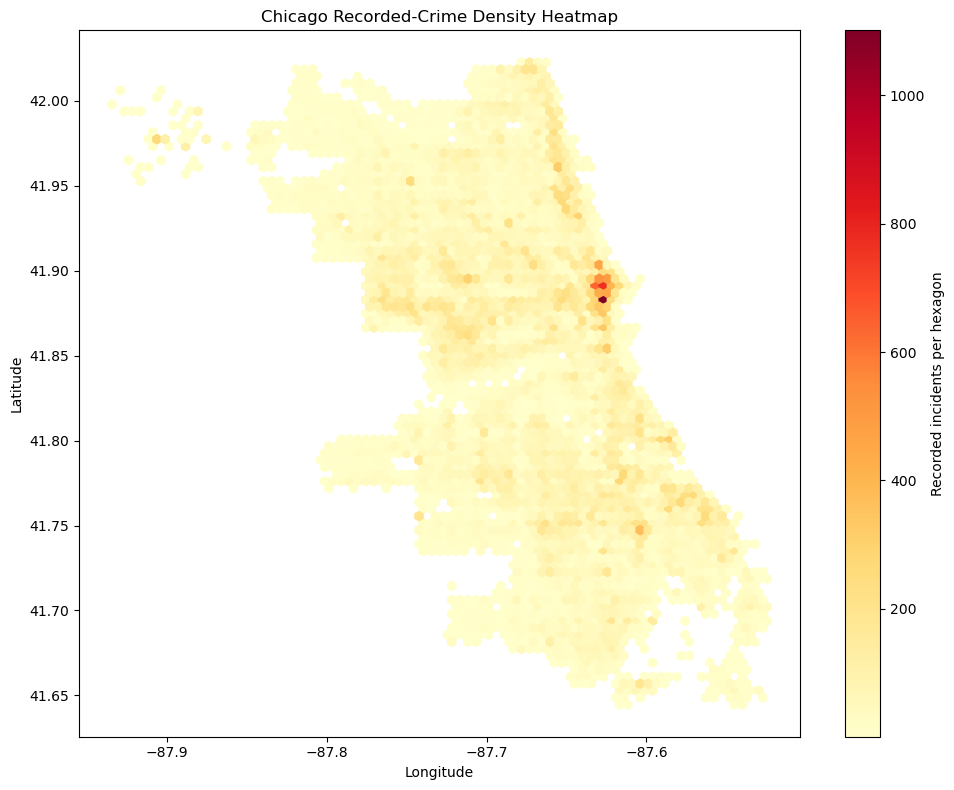

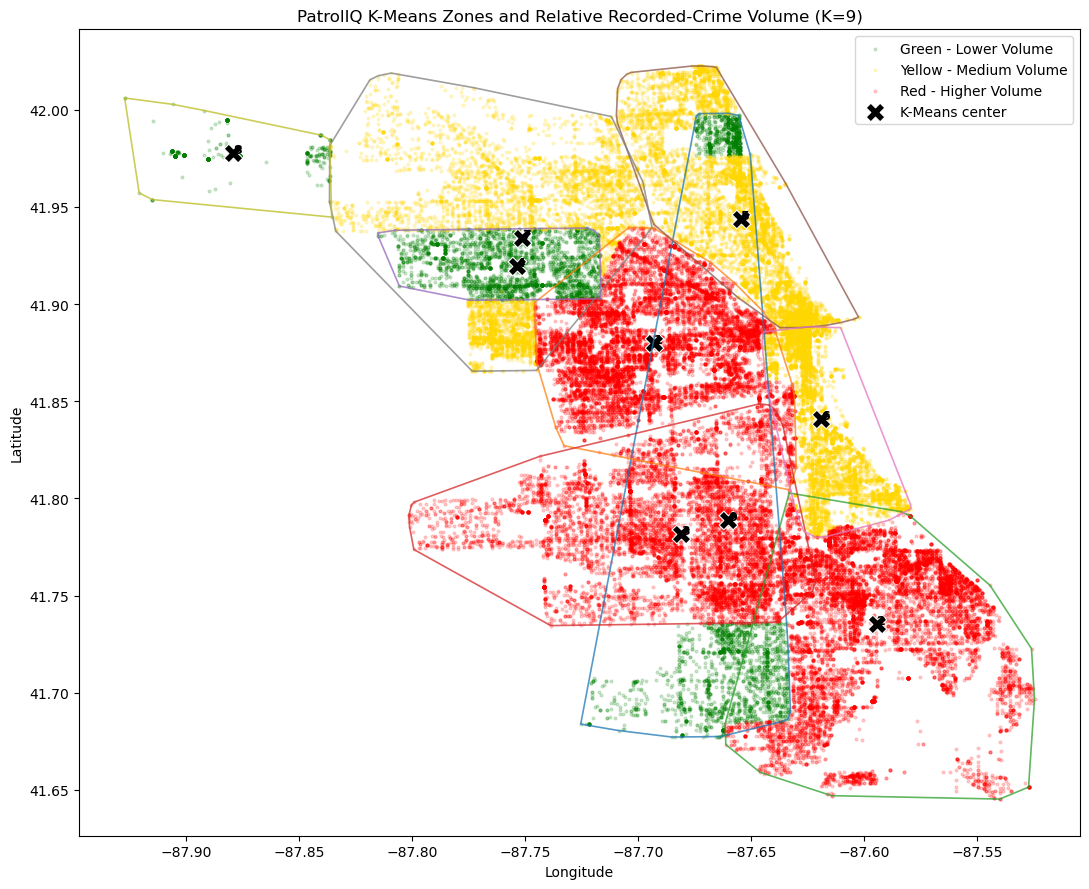

,Total_Crimes,Crime_Percentage,Dominant_Crime_Type,Arrest_Rate,Risk_Zone
KMeans_Cluster,,,,,
1,98448,19.69,THEFT,18.13,Red - Higher Volume
2,87472,17.49,BATTERY,14.06,Red - Higher Volume
3,85381,17.08,BATTERY,15.35,Red - Higher Volume
5,74447,14.89,THEFT,12.16,Yellow - Medium Volume
6,56699,11.34,THEFT,14.33,Yellow - Medium Volume
7,47205,9.44,THEFT,15.19,Yellow - Medium Volume
4,24949,4.99,THEFT,17.41,Green - Lower Volume
0,22074,4.41,THEFT,12.37,Green - Lower Volume
8,3325,0.66,THEFT,18.05,Green - Lower Volume



Risk-zone interpretation: relative recorded incident volume only; not population-adjusted/per-capita risk.


In [7]:
# ============================================================
# GEOGRAPHIC CRIME HEATMAP + K-MEANS RISK ZONES
# ============================================================

from scipy.spatial import ConvexHull

risk_map = cluster_profile["Risk_Zone"].astype(str).to_dict()
df["KMeans_Risk_Zone"] = df["KMeans_Cluster"].map(risk_map)

# 1) Recorded-crime density heatmap
heat_sample = df.sample(n=min(150000, len(df)), random_state=42)

plt.figure(figsize=(10, 8))
hb = plt.hexbin(
    heat_sample["Longitude"],
    heat_sample["Latitude"],
    gridsize=80,
    mincnt=1,
    cmap="YlOrRd"
)
plt.colorbar(hb, label="Recorded incidents per hexagon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Chicago Recorded-Crime Density Heatmap")
plt.tight_layout()
plt.show()

# 2)  K-Means zones with relative-volume risk bands
risk_colors = {
    "Green - Lower Volume": "green",
    "Yellow - Medium Volume": "gold",
    "Red - Higher Volume": "red"
}

zone_sample = df.sample(n=min(60000, len(df)), random_state=42)

plt.figure(figsize=(11, 9))

for risk_name in [
    "Green - Lower Volume",
    "Yellow - Medium Volume",
    "Red - Higher Volume"
]:
    part = zone_sample[zone_sample["KMeans_Risk_Zone"] == risk_name]
    plt.scatter(
        part["Longitude"],
        part["Latitude"],
        s=4,
        alpha=0.18,
        c=risk_colors[risk_name],
        label=risk_name
    )

# Approximate visible zone boundaries with convex hulls on sampled points.
for cluster_id in sorted(zone_sample["KMeans_Cluster"].unique()):
    points = (
        zone_sample.loc[
            zone_sample["KMeans_Cluster"] == cluster_id,
            ["Longitude", "Latitude"]
        ]
        .dropna()
        .to_numpy()
    )

    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]
            hull_points = np.vstack([hull_points, hull_points[0]])
            plt.plot(
                hull_points[:, 0],
                hull_points[:, 1],
                linewidth=1.2,
                alpha=0.75
            )
        except Exception:
            pass

plt.scatter(
    cluster_profile["Center_Longitude"],
    cluster_profile["Center_Latitude"],
    marker="X",
    s=180,
    c="black",
    edgecolors="white",
    linewidths=0.8,
    label="K-Means center"
)

for cluster_id, row in cluster_profile.iterrows():
    plt.text(
        row["Center_Longitude"],
        row["Center_Latitude"],
        str(cluster_id),
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"PatrolIQ K-Means Zones and Relative Recorded-Crime Volume (K={SELECTED_K})")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

risk_zone_summary = cluster_profile[
    [
        "Total_Crimes",
        "Crime_Percentage",
        "Dominant_Crime_Type",
        "Arrest_Rate",
        "Risk_Zone"
    ]
].sort_values("Total_Crimes", ascending=False)

display(risk_zone_summary.round(2))

print(
    "\nRisk-zone interpretation: relative recorded incident volume only; "
    "not population-adjusted/per-capita risk."
)


## A2 — DBSCAN Geographic Clustering

DBSCAN uses **projected X/Y coordinates only**. This preserves the meaning of spatial neighborhood distance and avoids treating Beat/District/Community Area identifiers as continuous physical distances.


### Step 6 — Prepare DBSCAN Spatial Coordinates


In [8]:
DBSCAN_FEATURES = ["X Coordinate", "Y Coordinate"]
dbscan_geo_df = df[DBSCAN_FEATURES].copy()
for col in DBSCAN_FEATURES:
    dbscan_geo_df[col] = pd.to_numeric(dbscan_geo_df[col], errors="coerce")

dbscan_geo_df.replace([np.inf, -np.inf], np.nan, inplace=True)
if dbscan_geo_df.isnull().any().any():
    raise ValueError("DBSCAN X/Y coordinates contain missing values after preprocessing.")

dbscan_scaler = StandardScaler()
dbscan_scaled = dbscan_scaler.fit_transform(dbscan_geo_df)

print("DBSCAN features:", DBSCAN_FEATURES)
print("DBSCAN matrix:", dbscan_scaled.shape)


DBSCAN features: ['X Coordinate', 'Y Coordinate']
DBSCAN matrix: (500000, 2)


### Step 7 — Initial DBSCAN Parameter Exploration on 30K Records


In [9]:
DBSCAN_SAMPLE_SIZE = 30000
rng = np.random.RandomState(42)
dbscan_sample_positions = rng.choice(
    len(dbscan_scaled), size=min(DBSCAN_SAMPLE_SIZE, len(dbscan_scaled)), replace=False
)
dbscan_sample = dbscan_scaled[dbscan_sample_positions]

eps_values = [0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]
MIN_SAMPLES = 20
sample_dbscan_results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1)
    labels = model.fit_predict(dbscan_sample)
    non_noise = labels != -1
    clusters = np.unique(labels[non_noise])
    n_clusters = len(clusters)
    noise_pct = (~non_noise).mean() * 100

    if non_noise.any():
        counts = pd.Series(labels[non_noise]).value_counts()
        largest_pct = counts.iloc[0] / len(labels) * 100
    else:
        largest_pct = np.nan

    sil = np.nan
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(
            dbscan_sample[non_noise], labels[non_noise],
            sample_size=min(10000, non_noise.sum()), random_state=42
        )

    sample_dbscan_results.append({
        "eps": eps, "min_samples": MIN_SAMPLES, "clusters": n_clusters,
        "noise_pct": noise_pct, "largest_cluster_pct": largest_pct,
        "silhouette": sil
    })
    print(f"eps={eps:.3f} | clusters={n_clusters} | noise={noise_pct:.2f}% | largest={largest_pct:.2f}% | silhouette={sil if pd.isna(sil) else round(sil,4)}")

sample_dbscan_results_df = pd.DataFrame(sample_dbscan_results)
display(sample_dbscan_results_df.round(4))


eps=0.010 | clusters=49 | noise=94.70% | largest=0.68% | silhouette=0.8151
eps=0.015 | clusters=75 | noise=89.46% | largest=2.16% | silhouette=0.5724
eps=0.020 | clusters=147 | noise=78.19% | largest=5.45% | silhouette=0.4732
eps=0.025 | clusters=170 | noise=63.90% | largest=6.60% | silhouette=0.3535
eps=0.030 | clusters=190 | noise=47.38% | largest=7.68% | silhouette=0.2091
eps=0.040 | clusters=113 | noise=25.70% | largest=20.46% | silhouette=-0.2201
eps=0.050 | clusters=58 | noise=10.59% | largest=72.56% | silhouette=-0.5043


,eps,min_samples,clusters,noise_pct,largest_cluster_pct,silhouette
0,0.010,20,49,94.7000,0.6833,0.8151
1,0.015,20,75,89.4600,2.1567,0.5724
2,0.020,20,147,78.1900,5.4500,0.4732
3,0.025,20,170,63.9033,6.6000,0.3535
4,0.030,20,190,47.3767,7.6767,0.2091
5,0.040,20,113,25.6967,20.4600,-0.2201
6,0.050,20,58,10.5933,72.5633,-0.5043


### Step 8 — K-Distance Diagnostic

The 20th-nearest-neighbor distance distribution provides a diagnostic for the `eps` neighborhood scale. The plot is guidance, not an automatic parameter selector.


20th-neighbor distance percentiles:
P50: 0.02777
P75: 0.03820
P85: 0.04466
P90: 0.04935
P95: 0.06061
P97: 0.07006
P99: 0.09256


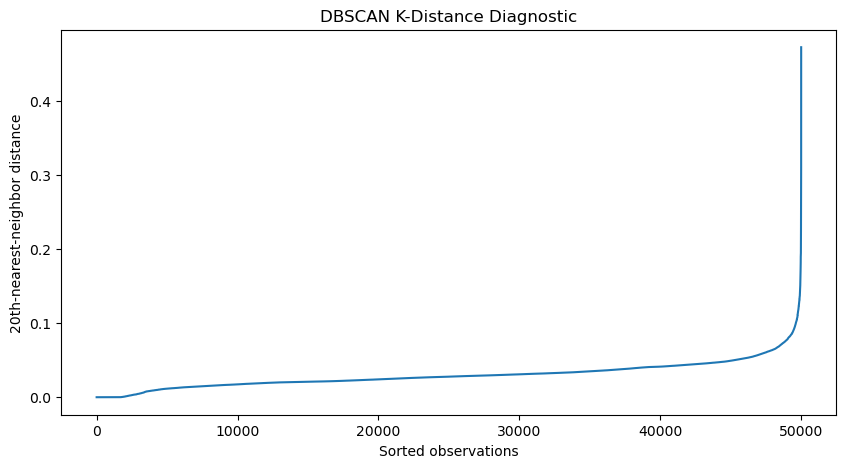

In [10]:
from sklearn.neighbors import NearestNeighbors

K_DISTANCE_SAMPLE = min(50000, len(dbscan_scaled))
rng = np.random.RandomState(42)
kdist_positions = rng.choice(len(dbscan_scaled), size=K_DISTANCE_SAMPLE, replace=False)
kdist_data = dbscan_scaled[kdist_positions]

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
neighbors.fit(kdist_data)
distances, _ = neighbors.kneighbors(kdist_data)
k_distances = np.sort(distances[:, -1])

print("20th-neighbor distance percentiles:")
for p in [50, 75, 85, 90, 95, 97, 99]:
    print(f"P{p}: {np.percentile(k_distances, p):.5f}")

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Sorted observations")
plt.ylabel(f"{MIN_SAMPLES}th-nearest-neighbor distance")
plt.title("DBSCAN K-Distance Diagnostic")
plt.show()


### Step 9 — Evaluate Selected DBSCAN Candidates on All 500K Records

A small candidate set is evaluated on the full dataset. DBSCAN is retained primarily for density/noise analysis; it is not forced to behave like K-Means.


In [11]:
# Candidate values centered on the useful range from the initial exploration.
# Edit this list only if the Step 7/8 output clearly indicates a different scale.
FULL_DBSCAN_EPS = [0.015, 0.018, 0.020, 0.025]
FULL_DBSCAN_MIN_SAMPLES = 20
full_dbscan_results = []
full_dbscan_models = {}

for eps in FULL_DBSCAN_EPS:
    print(f"\nFitting full DBSCAN eps={eps:.3f} ...")
    model = DBSCAN(eps=eps, min_samples=FULL_DBSCAN_MIN_SAMPLES, n_jobs=-1)
    labels = model.fit_predict(dbscan_scaled)
    non_noise = labels != -1
    n_clusters = len(np.unique(labels[non_noise]))
    noise_pct = (~non_noise).mean() * 100

    if non_noise.any():
        counts = pd.Series(labels[non_noise]).value_counts()
        largest_pct = counts.iloc[0] / len(labels) * 100
    else:
        largest_pct = np.nan

    sil = np.nan
    db = np.nan
    non_noise_idx = np.where(non_noise)[0]
    if n_clusters >= 2 and len(non_noise_idx) > n_clusters:
        rng = np.random.RandomState(42)
        eval_idx = rng.choice(non_noise_idx, size=min(30000, len(non_noise_idx)), replace=False)
        sil = silhouette_score(dbscan_scaled[eval_idx], labels[eval_idx])
        db = davies_bouldin_score(dbscan_scaled[eval_idx], labels[eval_idx])

    full_dbscan_results.append({
        "eps": eps, "min_samples": FULL_DBSCAN_MIN_SAMPLES,
        "clusters": n_clusters, "noise_pct": noise_pct,
        "largest_cluster_pct": largest_pct, "silhouette": sil,
        "Davies_Bouldin": db
    })
    full_dbscan_models[eps] = (model, labels)
    print(f"clusters={n_clusters} | noise={noise_pct:.2f}% | largest={largest_pct:.2f}% | silhouette={sil if pd.isna(sil) else round(sil,4)}")

full_dbscan_results_df = pd.DataFrame(full_dbscan_results)
display(full_dbscan_results_df.round(4))



Fitting full DBSCAN eps=0.015 ...
clusters=1049 | noise=6.37% | largest=27.41% | silhouette=-0.5818

Fitting full DBSCAN eps=0.018 ...
clusters=506 | noise=2.93% | largest=82.52% | silhouette=-0.7329

Fitting full DBSCAN eps=0.020 ...
clusters=315 | noise=1.92% | largest=91.25% | silhouette=-0.7498

Fitting full DBSCAN eps=0.025 ...
clusters=110 | noise=0.59% | largest=96.24% | silhouette=-0.6938


,eps,min_samples,clusters,noise_pct,largest_cluster_pct,silhouette,Davies_Bouldin
0,0.015,20,1049,6.3694,27.4050,-0.5818,0.8185
1,0.018,20,506,2.9302,82.5182,-0.7329,1.0337
2,0.020,20,315,1.9200,91.2544,-0.7498,0.8085
3,0.025,20,110,0.5936,96.2376,-0.6938,2.2433


### Step 10 — Select a Representative DBSCAN Result

For comparison, prefer a candidate with at least two clusters, manageable noise, and no single cluster containing more than 90% of all records. Within that practical subset, choose the highest Silhouette score. If no candidate meets those constraints, choose the highest available Silhouette and report the limitation.


In [12]:
valid_dbscan = full_dbscan_results_df[
    (full_dbscan_results_df["clusters"] >= 2) &
    (full_dbscan_results_df["noise_pct"] <= 30) &
    (full_dbscan_results_df["largest_cluster_pct"] <= 90) &
    (full_dbscan_results_df["silhouette"].notna())
].copy()

if valid_dbscan.empty:
    valid_dbscan = full_dbscan_results_df[
        full_dbscan_results_df["silhouette"].notna()
    ].copy()
    print("No candidate met all practical constraints; selecting highest available silhouette for representative comparison.")

if valid_dbscan.empty:
    raise ValueError("No DBSCAN candidate produced at least two evaluable non-noise clusters.")

best_dbscan_row = valid_dbscan.sort_values(
    ["silhouette", "Davies_Bouldin"], ascending=[False, True]
).iloc[0]

SELECTED_DBSCAN_EPS = float(best_dbscan_row["eps"])
selected_dbscan, selected_dbscan_labels = full_dbscan_models[SELECTED_DBSCAN_EPS]
df["DBSCAN_Cluster"] = selected_dbscan_labels

selected_dbscan_silhouette = float(best_dbscan_row["silhouette"])
selected_dbscan_db = float(best_dbscan_row["Davies_Bouldin"])

print("Representative DBSCAN eps:", SELECTED_DBSCAN_EPS)
print("min_samples:", FULL_DBSCAN_MIN_SAMPLES)
print("Clusters:", int(best_dbscan_row["clusters"]))
print(f"Noise: {best_dbscan_row['noise_pct']:.2f}%")
print(f"Largest cluster: {best_dbscan_row['largest_cluster_pct']:.2f}%")
print(f"Silhouette: {selected_dbscan_silhouette:.4f}")
print(f"Davies-Bouldin: {selected_dbscan_db:.4f}")


Representative DBSCAN eps: 0.015
min_samples: 20
Clusters: 1049
Noise: 6.37%
Largest cluster: 27.41%
Silhouette: -0.5818
Davies-Bouldin: 0.8185


### Step 11 — Visualize the Representative DBSCAN Result


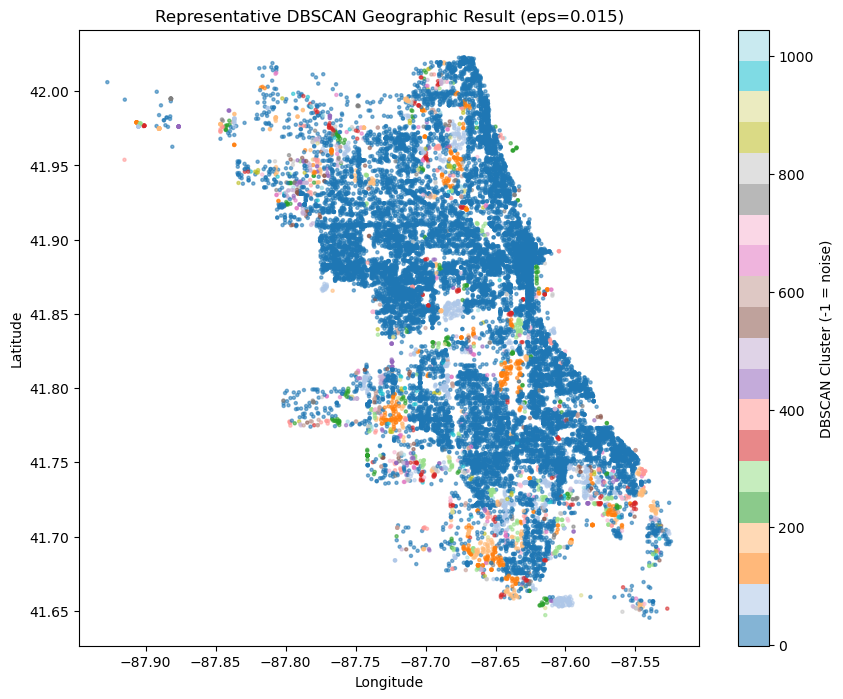

In [13]:
db_plot = df.sample(n=min(20000, len(df)), random_state=42)
plt.figure(figsize=(10, 8))
plt.scatter(
    db_plot["Longitude"], db_plot["Latitude"],
    c=db_plot["DBSCAN_Cluster"], s=5, alpha=0.55, cmap="tab20"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Representative DBSCAN Geographic Result (eps={SELECTED_DBSCAN_EPS:.3f})")
plt.colorbar(label="DBSCAN Cluster (-1 = noise)")
plt.show()


## A3 — Hierarchical Geographic Clustering

Hierarchical clustering uses the same patrol-focused standardized feature representation as K-Means, but is evaluated on a reproducible 10,000-record sample because agglomerative clustering is too expensive for all 500,000 rows.


### Step 12 — Evaluate Hierarchical Clustering for K = 5 to 10


In [14]:
HIER_SAMPLE_SIZE = 10000
rng = np.random.RandomState(42)
hier_positions = rng.choice(
    len(kmeans_geo_scaled), size=min(HIER_SAMPLE_SIZE, len(kmeans_geo_scaled)), replace=False
)
hier_geo = kmeans_geo_scaled[hier_positions]

hierarchical_results = []
hierarchical_models = {}

for k in range(5, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(hier_geo)
    sil = silhouette_score(hier_geo, labels)
    db = davies_bouldin_score(hier_geo, labels)
    hierarchical_results.append({"K":k, "Silhouette":sil, "Davies_Bouldin":db})
    hierarchical_models[k] = (agg, labels)
    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f}")

hierarchical_results_df = pd.DataFrame(hierarchical_results)
display(hierarchical_results_df.round(4))

best_hier_row = hierarchical_results_df.sort_values(
    ["Silhouette", "Davies_Bouldin"], ascending=[False, True]
).iloc[0]
SELECTED_HIER_K = int(best_hier_row["K"])
selected_hier_silhouette = float(best_hier_row["Silhouette"])
selected_hier_db = float(best_hier_row["Davies_Bouldin"])
print(f"\nRepresentative Hierarchical K={SELECTED_HIER_K}")


K=5 | Silhouette=0.4240 | DB=1.0154
K=6 | Silhouette=0.4526 | DB=0.8976
K=7 | Silhouette=0.4653 | DB=0.8376
K=8 | Silhouette=0.4869 | DB=0.8345
K=9 | Silhouette=0.5083 | DB=0.7549
K=10 | Silhouette=0.5170 | DB=0.6240


,K,Silhouette,Davies_Bouldin
0,5,0.4240,1.0154
1,6,0.4526,0.8976
2,7,0.4653,0.8376
3,8,0.4869,0.8345
4,9,0.5083,0.7549
5,10,0.5170,0.6240



Representative Hierarchical K=10


### Step 13 — Hierarchical Dendrogram


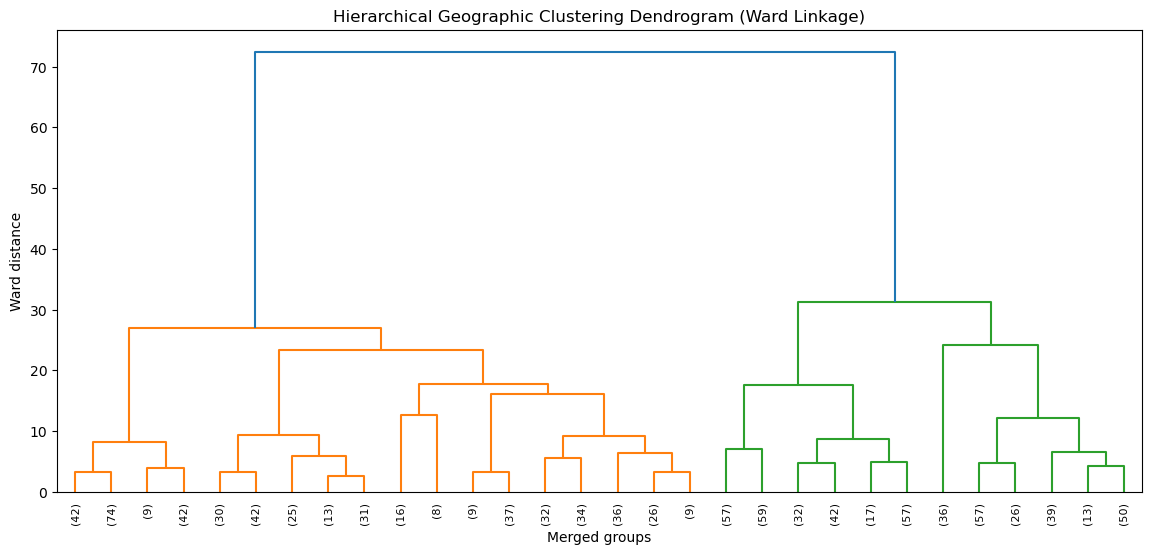

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram

DENDROGRAM_SAMPLE = min(1000, len(hier_geo))
dendro_data = hier_geo[:DENDROGRAM_SAMPLE]
linkage_matrix = linkage(dendro_data, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Geographic Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Merged groups")
plt.ylabel("Ward distance")
plt.show()


### Step 13A — Hierarchical Cluster Profiles and Scalability Note

Standard Ward/Agglomerative hierarchical clustering is evaluated on a reproducible
10,000-record sample. Running ordinary hierarchical clustering on all 500,000 records
would be computationally impractical because of its memory and time scaling, and a
500,000-leaf dendrogram would not be interpretable.

The representative sample is used for hierarchical relationships, metrics, cluster
profiles, and the dendrogram. K-Means remains the scalable full-dataset deployment
segmentation.


In [16]:
# ============================================================
# HIERARCHICAL CLUSTER PROFILES — REPRESENTATIVE SAMPLE
# ============================================================

selected_hier_model, selected_hier_labels = hierarchical_models[SELECTED_HIER_K]

hier_profile_df = df.iloc[hier_positions].copy()
hier_profile_df["Hierarchical_Cluster"] = selected_hier_labels

hierarchical_profile = (
    hier_profile_df.groupby("Hierarchical_Cluster")
    .agg(
        Total_Crimes=("Hierarchical_Cluster", "size"),
        Center_Latitude=("Latitude", "mean"),
        Center_Longitude=("Longitude", "mean"),
        Dominant_Crime_Type=("Primary Type", dominant_value),
        Dominant_Location=("Location Description", dominant_value),
        Dominant_District=("District", dominant_value),
        Arrest_Rate=("Arrest", "mean"),
        Domestic_Rate=("Domestic", "mean"),
        Avg_Severity=("Crime_Severity_Score", "mean")
    )
)

hierarchical_profile["Arrest_Rate"] *= 100
hierarchical_profile["Domestic_Rate"] *= 100

print(
    f"Hierarchical profile sample: {len(hier_profile_df):,} records | "
    f"K={SELECTED_HIER_K}"
)
display(hierarchical_profile.round(3))

print(
    "\nScalability decision: full 500K standard agglomerative/Ward fitting "
    "is intentionally not attempted; K-Means provides the scalable full-data segmentation."
)


Hierarchical profile sample: 10,000 records | K=10


,Total_Crimes,Center_Latitude,Center_Longitude,Dominant_Crime_Type,Dominant_Location,Dominant_District,Arrest_Rate,Domestic_Rate,Avg_Severity
Hierarchical_Cluster,,,,,,,,,
0,1882,41.780,-87.674,BATTERY,STREET,8,15.250,23.433,3.734
1,1453,41.944,-87.655,THEFT,STREET,19,13.214,9.704,3.798
2,1278,41.834,-87.617,THEFT,STREET,1,13.302,15.102,3.719
3,2063,41.881,-87.693,THEFT,STREET,12,17.596,17.014,3.777
4,1376,41.725,-87.591,BATTERY,STREET,4,13.517,27.980,3.799
5,285,41.711,-87.661,THEFT,RESIDENCE,22,14.386,20.000,3.593
6,140,41.987,-87.662,THEFT,APARTMENT,20,14.286,14.286,3.757
7,949,41.936,-87.753,THEFT,STREET,15,14.752,22.023,3.673
8,510,41.918,-87.753,THEFT,STREET,25,14.510,19.804,3.749



Scalability decision: full 500K standard agglomerative/Ward fitting is intentionally not attempted; K-Means provides the scalable full-data segmentation.


## A4 — Geographic Model Comparison and Selection


### Step 14 — Compare K-Means, DBSCAN, and Hierarchical Clustering


In [17]:
comparison = pd.DataFrame({
    "Algorithm": [
        f"K-Means (K={SELECTED_K})",
        f"DBSCAN (eps={SELECTED_DBSCAN_EPS:.3f})",
        f"Hierarchical (K={SELECTED_HIER_K})"
    ],
    "Silhouette_Score": [
        selected_geo_silhouette,
        selected_dbscan_silhouette,
        selected_hier_silhouette
    ],
    "Davies_Bouldin_Score": [
        selected_geo_db,
        selected_dbscan_db,
        selected_hier_db
    ],
    "Evaluation_Data": [
        "500K fit / 30K evaluation sample",
        "500K fit / 30K non-noise evaluation sample",
        "10K sample"
    ],
    "Role": [
        "Primary patrol-zone segmentation",
        "Density/noise hotspot analysis",
        "Hierarchical structure comparison"
    ]
})

display(comparison.style.format({
    "Silhouette_Score":"{:.4f}", "Davies_Bouldin_Score":"{:.4f}"
}))

print(f"\nSelected deployment segmentation: K-Means K={SELECTED_K}")
print("Reason: all records are assigned to interpretable patrol-oriented zones, while DBSCAN is retained for density/noise analysis and Hierarchical clustering for structural comparison.")


,Algorithm,Silhouette_Score,Davies_Bouldin_Score,Evaluation_Data,Role
0,K-Means (K=9),0.5012,0.7153,500K fit / 30K evaluation sample,Primary patrol-zone segmentation
1,DBSCAN (eps=0.015),-0.5818,0.8185,500K fit / 30K non-noise evaluation sample,Density/noise hotspot analysis
2,Hierarchical (K=10),0.5170,0.6240,10K sample,Hierarchical structure comparison



Selected deployment segmentation: K-Means K=9
Reason: all records are assigned to interpretable patrol-oriented zones, while DBSCAN is retained for density/noise analysis and Hierarchical clustering for structural comparison.


## Part B — Temporal Pattern Clustering


### Step 15 — Prepare Temporal Features
Use the project-required temporal variables: **Hour, Day of Week, and Month**. Day names are converted to ordered numeric values and the three features are standardized.


In [18]:
# ============================================================
# TEMPORAL CLUSTERING FEATURE PREPARATION
# Project requirement: Hour + Day + Month
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Convert Day_of_Week to ordered numeric values
# Monday = 0 ... Sunday = 6
# ------------------------------------------------------------

day_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["Day_of_Week_Num"] = df["Day_of_Week"].map(day_mapping)


# ------------------------------------------------------------
# 2. Select temporal clustering features
# ------------------------------------------------------------

temporal_features = df[
    [
        "Hour",
        "Day_of_Week_Num",
        "Month"
    ]
].copy()


# ------------------------------------------------------------
# 3. Validate before scaling
# ------------------------------------------------------------

print("Temporal Feature Summary:")
print(temporal_features.describe())

print(
    "\nMissing values:",
    temporal_features.isnull().sum().sum()
)


# ------------------------------------------------------------
# 4. Standardize temporal features
# ------------------------------------------------------------

temporal_scaler = StandardScaler()

temporal_scaled = temporal_scaler.fit_transform(
    temporal_features
)


print(
    "\nTemporal scaled shape:",
    temporal_scaled.shape
)

print(
    "Temporal features:",
    list(temporal_features.columns)
)


Temporal Feature Summary:
                Hour  Day_of_Week_Num          Month
count  500000.000000    500000.000000  500000.000000
mean       12.492562         3.024506       6.589138
std         6.829309         2.000248       3.281491
min         0.000000         0.000000       1.000000
25%         8.000000         1.000000       4.000000
50%        13.000000         3.000000       7.000000
75%        18.000000         5.000000       9.000000
max        23.000000         6.000000      12.000000

Missing values: 0

Temporal scaled shape: (500000, 3)
Temporal features: ['Hour', 'Day_of_Week_Num', 'Month']


### Step 16 — Temporal Elbow Method
Inspect inertia across candidate temporal cluster counts before evaluating the project's expected 3–5 pattern range.


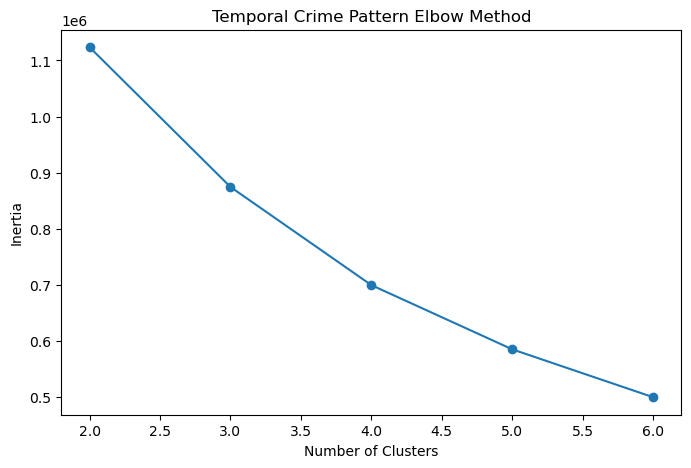

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(temporal_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,7),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Temporal Crime Pattern Elbow Method")

plt.show()


### Step 17 — Evaluate Temporal K-Means for K = 3 to 5
Compare Silhouette and Davies-Bouldin scores before selecting the temporal model.


In [20]:
# ============================================================
# TEMPORAL K-MEANS EVALUATION: K = 3 TO 5
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

temporal_results = {}

for k in range(3, 6):

    kmeans_time = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train on all 500,000 temporal records
    labels = kmeans_time.fit_predict(
        temporal_scaled
    )

    # Silhouette evaluated on reproducible 30K sample
    sil_score = silhouette_score(
        temporal_scaled,
        labels,
        sample_size=30000,
        random_state=42
    )

    # Davies-Bouldin evaluated on full dataset
    db_score = davies_bouldin_score(
        temporal_scaled,
        labels
    )

    temporal_results[k] = {
        "silhouette": sil_score,
        "davies_bouldin": db_score
    }

    print(
        f"K={k} | "
        f"Silhouette = {sil_score:.4f} | "
        f"Davies-Bouldin = {db_score:.4f}"
    )


# ------------------------------------------------------------
# Metric summaries
# ------------------------------------------------------------

best_temporal_sil_k = max(
    temporal_results,
    key=lambda k: temporal_results[k]["silhouette"]
)

best_temporal_db_k = min(
    temporal_results,
    key=lambda k: temporal_results[k]["davies_bouldin"]
)

print("\n" + "=" * 65)
print("TEMPORAL K-MEANS EVALUATION SUMMARY")
print("=" * 65)

print(
    f"Highest Silhouette    : "
    f"K={best_temporal_sil_k} "
    f"({temporal_results[best_temporal_sil_k]['silhouette']:.4f})"
)

print(
    f"Lowest Davies-Bouldin : "
    f"K={best_temporal_db_k} "
    f"({temporal_results[best_temporal_db_k]['davies_bouldin']:.4f})"
)


K=3 | Silhouette = 0.2543 | Davies-Bouldin = 1.3169
K=4 | Silhouette = 0.2702 | Davies-Bouldin = 1.1331
K=5 | Silhouette = 0.2683 | Davies-Bouldin = 1.0947

TEMPORAL K-MEANS EVALUATION SUMMARY
Highest Silhouette    : K=4 (0.2702)
Lowest Davies-Bouldin : K=5 (1.0947)


### Step 18 — Train the Temporal K-Means Model (K = 4)
K=4 is selected because it provides the strongest Silhouette Score among K=3–5 while maintaining a competitive Davies-Bouldin score.


In [21]:
# ============================================================
#  TEMPORAL K-MEANS MODEL
# Selected K = 4 based on temporal clustering evaluation
# ============================================================

from sklearn.cluster import KMeans

SELECTED_TEMPORAL_K = 4

kmeans_time = KMeans(
    n_clusters=SELECTED_TEMPORAL_K,
    random_state=42,
    n_init=10
)

df["Temporal_Cluster"] = kmeans_time.fit_predict(
    temporal_scaled
)

print(" Temporal K:", SELECTED_TEMPORAL_K)

print("\nTemporal Cluster Distribution:")
print(
    df["Temporal_Cluster"]
    .value_counts()
    .sort_index()
)

print("\nTemporal Cluster Percentages:")
print(
    (
        df["Temporal_Cluster"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)


selected Temporal K: 4

Temporal Cluster Distribution:
Temporal_Cluster
0    108807
1    125908
2    125436
3    139849
Name: count, dtype: int64

Temporal Cluster Percentages:
Temporal_Cluster
0    21.76
1    25.18
2    25.09
3    27.97
Name: proportion, dtype: float64


### Step 19 — Profile the Temporal Clusters
Summarize cluster size, average hour/day/month, weekend share, average severity, and each cluster's peak recorded hour, day, and month.


In [22]:
# ============================================================
# TEMPORAL CLUSTER PROFILING
# ============================================================

# Basic cluster statistics
cluster_summary = (
    df.groupby("Temporal_Cluster")
    .agg(
        Total_Crimes=("Temporal_Cluster", "size"),
        Avg_Hour=("Hour", "mean"),
        Avg_Day=("Day_of_Week_Num", "mean"),
        Avg_Month=("Month", "mean"),
        Weekend_Rate=("Is_Weekend", "mean"),
        Avg_Severity=("Crime_Severity_Score", "mean")
    )
)

# Convert weekend proportion to percentage
cluster_summary["Weekend_Rate"] *= 100


# Most common temporal values in each cluster
cluster_summary["Peak_Hour"] = (
    df.groupby("Temporal_Cluster")["Hour"]
    .agg(lambda x: x.mode().iloc[0])
)

cluster_summary["Peak_Day"] = (
    df.groupby("Temporal_Cluster")["Day_of_Week"]
    .agg(lambda x: x.mode().iloc[0])
)

cluster_summary["Peak_Month"] = (
    df.groupby("Temporal_Cluster")["Month"]
    .agg(lambda x: x.mode().iloc[0])
)


# Round numeric values for readability
cluster_summary = cluster_summary.round(2)

print("Temporal Cluster Profiles:")
print(cluster_summary)


Temporal Cluster Profiles:
                  Total_Crimes  Avg_Hour  Avg_Day  Avg_Month  Weekend_Rate  \
Temporal_Cluster                                                             
0                       108807      3.56     4.21       6.66         49.20   
1                       125908     13.76     1.42       9.65          0.00   
2                       125436     13.63     1.53       3.41          0.34   
3                       139849     17.28     4.89       6.63         64.93   

                  Avg_Severity  Peak_Hour  Peak_Day  Peak_Month  
Temporal_Cluster                                                 
0                         3.74          0  Saturday           5  
1                         3.77         12    Monday          12  
2                         3.74         12    Monday           5  
3                         3.75         19  Saturday           5  


### Step 20A — Detailed Temporal Crime Profiles

Add dominant crime type, dominant location, and a descriptive pattern label so the
3–5 temporal clusters can be interpreted as meaningful crime-behavior profiles.


In [23]:
# ============================================================
# DETAILED TEMPORAL CRIME PROFILES
# ============================================================

temporal_detail = cluster_summary.copy()

temporal_detail["Dominant_Crime_Type"] = (
    df.groupby("Temporal_Cluster")["Primary Type"].agg(dominant_value)
)

temporal_detail["Dominant_Location"] = (
    df.groupby("Temporal_Cluster")["Location Description"].agg(dominant_value)
)

def hour_period(hour):
    hour = int(round(hour)) % 24
    if 0 <= hour < 6:
        return "Late Night / Early Morning"
    if 6 <= hour < 12:
        return "Morning"
    if 12 <= hour < 17:
        return "Afternoon"
    if 17 <= hour < 21:
        return "Evening"
    return "Night"

temporal_detail["Pattern_Label"] = [
    (
        f"{hour_period(row['Avg_Hour'])} | "
        f"{'Weekend-heavy' if row['Weekend_Rate'] >= 40 else 'Mostly weekday'} | "
        f"Peak {row['Peak_Day']}"
    )
    for _, row in temporal_detail.iterrows()
]

display(temporal_detail)

print(
    "\nThese labels describe recorded-crime patterns in the dataset; "
    "they are not predictions of future crime."
)


,Total_Crimes,Avg_Hour,Avg_Day,Avg_Month,Weekend_Rate,Avg_Severity,Peak_Hour,Peak_Day,Peak_Month,Dominant_Crime_Type,Dominant_Location,Pattern_Label
Temporal_Cluster,,,,,,,,,,,,
0,108807,3.56,4.21,6.66,49.20,3.74,0,Saturday,5,BATTERY,STREET,Late Night / Early Morning | Weekend-heavy | P...
1,125908,13.76,1.42,9.65,0.00,3.77,12,Monday,12,THEFT,STREET,Afternoon | Mostly weekday | Peak Monday
2,125436,13.63,1.53,3.41,0.34,3.74,12,Monday,5,THEFT,STREET,Afternoon | Mostly weekday | Peak Monday
3,139849,17.28,4.89,6.63,64.93,3.75,19,Saturday,5,THEFT,STREET,Evening | Weekend-heavy | Peak Saturday



These labels describe recorded-crime patterns in the dataset; they are not predictions of future crime.


### Step 21 — Identify Overall Peak Recorded Time Periods
Report the most frequent recorded hour, day, month, and season in the 500,000-record analysis window. These are raw recorded frequencies, not exposure-adjusted risk rates.


In [24]:
# Identify peak crime time periods and seasonal patterns

peak_hour = df["Hour"].value_counts().idxmax()
peak_hour_count = df["Hour"].value_counts().max()

peak_day = df["Day_of_Week"].value_counts().idxmax()
peak_day_count = df["Day_of_Week"].value_counts().max()

peak_month = df["Month"].value_counts().idxmax()
peak_month_count = df["Month"].value_counts().max()

peak_season = df["Season"].value_counts().idxmax()
peak_season_count = df["Season"].value_counts().max()

print("Peak Crime Time Periods")
print("-----------------------")
print(f"Peak Hour   : {peak_hour}:00 ({peak_hour_count:,} incidents)")
print(f"Peak Day    : {peak_day} ({peak_day_count:,} incidents)")
print(f"Peak Month  : {peak_month} ({peak_month_count:,} incidents)")
print(f"Peak Season : {peak_season} ({peak_season_count:,} incidents)")


Peak Crime Time Periods
-----------------------
Peak Hour   : 0:00 (33,784 incidents)
Peak Day    : Friday (74,135 incidents)
Peak Month  : 5 (58,779 incidents)
Peak Season : Summer (135,197 incidents)


### Step 21A — Monthly and Seasonal Crime Patterns

This explicitly evaluates the seasonal component requested by the project.

**Coverage caution:** raw totals can be affected by the finite observation window, so
these are descriptive recorded-incident counts rather than exposure-adjusted seasonal
crime rates.


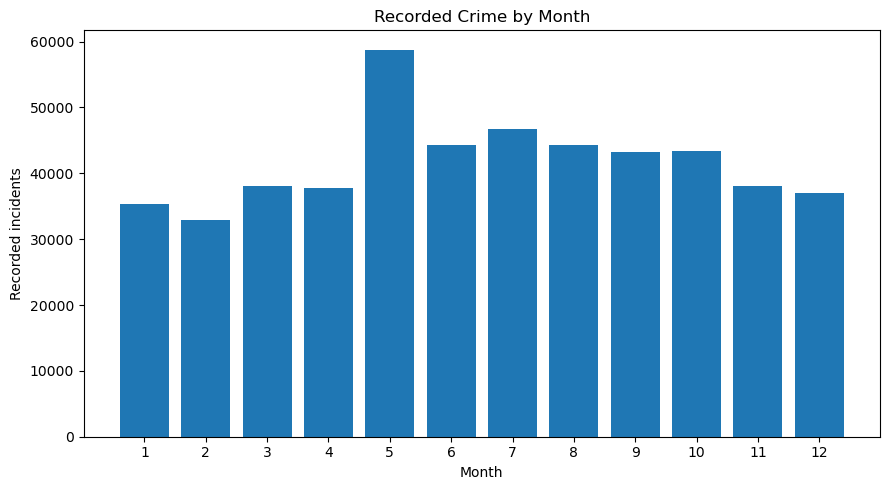

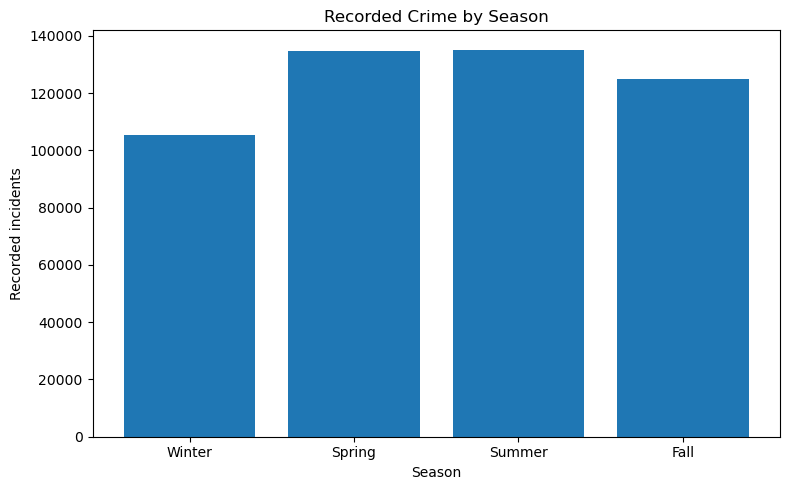

,Recorded_Incidents,Percentage
Season,,
Winter,105325,21.06
Spring,134687,26.94
Summer,135197,27.04
Fall,124791,24.96


Peak recorded month  : 5
Peak recorded season : Summer
Caution: these are raw recorded-incident totals for the available observation window.


In [25]:
# ============================================================
# MONTHLY + SEASONAL RECORDED-CRIME ANALYSIS
# ============================================================

month_counts = df["Month"].value_counts().sort_index()

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_counts = (
    df["Season"]
    .value_counts()
    .reindex(season_order)
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(9, 5))
plt.bar(month_counts.index.astype(str), month_counts.values)
plt.xlabel("Month")
plt.ylabel("Recorded incidents")
plt.title("Recorded Crime by Month")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.xlabel("Season")
plt.ylabel("Recorded incidents")
plt.title("Recorded Crime by Season")
plt.tight_layout()
plt.show()

seasonal_summary = pd.DataFrame({
    "Recorded_Incidents": season_counts,
    "Percentage": (season_counts / season_counts.sum() * 100).round(2)
})

display(seasonal_summary)

print(f"Peak recorded month  : {peak_month}")
print(f"Peak recorded season : {peak_season}")
print(
    "Caution: these are raw recorded-incident totals for the available observation window."
)


### Step 21B — Weekday vs Weekend Crime Patterns

This explicitly compares weekday and weekend recorded-crime behavior. Because weekdays
cover five days and weekends cover two, total counts should not be interpreted as
equal-exposure daily risk.


,Total_Crimes,Arrest_Rate,Domestic_Rate,Avg_Severity,Crime_Percentage
Day_Group,,,,,
Weekday,355238,15.00,17.80,3.75,71.05
Weekend,144762,15.18,21.37,3.74,28.95


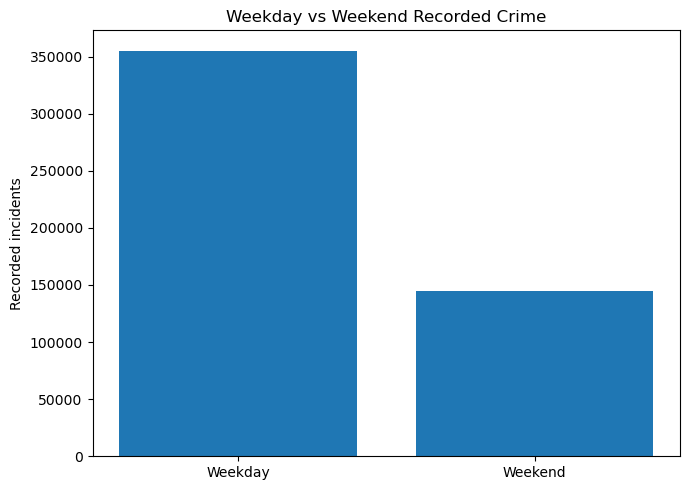

Interpretation caution: weekdays contain five calendar days and weekends two.


In [26]:
# ============================================================
# WEEKDAY VS WEEKEND COMPARISON
# ============================================================

weekday_weekend = (
    df.assign(
        Day_Group=np.where(
            df["Is_Weekend"].astype(bool),
            "Weekend",
            "Weekday"
        )
    )
    .groupby("Day_Group")
    .agg(
        Total_Crimes=("Temporal_Cluster", "size"),
        Arrest_Rate=("Arrest", "mean"),
        Domestic_Rate=("Domestic", "mean"),
        Avg_Severity=("Crime_Severity_Score", "mean")
    )
)

weekday_weekend["Arrest_Rate"] *= 100
weekday_weekend["Domestic_Rate"] *= 100
weekday_weekend["Crime_Percentage"] = (
    weekday_weekend["Total_Crimes"] / len(df) * 100
)

display(weekday_weekend.round(2))

plt.figure(figsize=(7, 5))
plt.bar(weekday_weekend.index, weekday_weekend["Total_Crimes"])
plt.ylabel("Recorded incidents")
plt.title("Weekday vs Weekend Recorded Crime")
plt.tight_layout()
plt.show()

print(
    "Interpretation caution: weekdays contain five calendar days and weekends two."
)


### Step 21C — Hour × Day-of-Week Crime Heatmap

This heatmap shows when recorded incidents are concentrated across the week and directly
satisfies the requested hourly temporal heatmap.


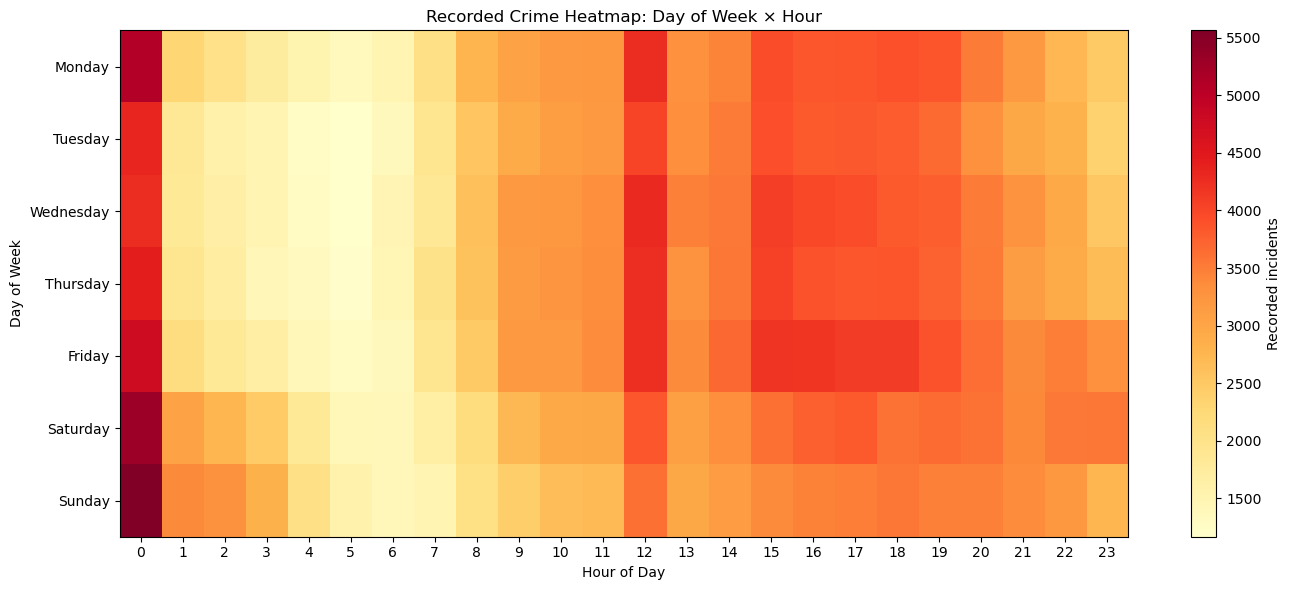

Highest day-hour cell: Sunday at 00:00 (5,564 recorded incidents)


In [27]:
# ============================================================
# HOURLY HEATMAP — DAY OF WEEK × HOUR
# ============================================================

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hourly_heatmap = pd.crosstab(
    pd.Categorical(
        df["Day_of_Week"],
        categories=day_order,
        ordered=True
    ),
    df["Hour"]
).reindex(index=day_order, columns=range(24), fill_value=0)

plt.figure(figsize=(14, 6))
img = plt.imshow(
    hourly_heatmap.values,
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd"
)
plt.colorbar(img, label="Recorded incidents")
plt.xticks(range(24), range(24))
plt.yticks(range(len(day_order)), day_order)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Recorded Crime Heatmap: Day of Week × Hour")
plt.tight_layout()
plt.show()

max_pos = np.unravel_index(
    np.argmax(hourly_heatmap.values),
    hourly_heatmap.shape
)

heatmap_peak_day = hourly_heatmap.index[max_pos[0]]
heatmap_peak_hour = int(hourly_heatmap.columns[max_pos[1]])
heatmap_peak_count = int(hourly_heatmap.iloc[max_pos])

print(
    f"Highest day-hour cell: {heatmap_peak_day} at "
    f"{heatmap_peak_hour:02d}:00 "
    f"({heatmap_peak_count:,} recorded incidents)"
)


## Part C — Validation and Export


### Step 22 — Validate and Save the Clustered Dataset


In [28]:
# ============================================================
#  STEP 4 VALIDATION + EXPORT
# ============================================================

OUTPUT_PATH = "../data/processed/chicago_crime_clustered.csv"

required_cluster_columns = [
    "KMeans_Cluster",
    "KMeans_Risk_Zone",
    "DBSCAN_Cluster",
    "Temporal_Cluster"
]

missing_columns = [c for c in required_cluster_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing clustering columns: {missing_columns}")

print(" STEP 4 CLUSTERING VALIDATION")
print("=" * 72)
print("Dataset shape:", df.shape)

print("\n1) Geographic K-Means")
print("-" * 40)
print(" K:", SELECTED_K)
print(f"Silhouette: {selected_geo_silhouette:.4f}")
print(f"Davies-Bouldin: {selected_geo_db:.4f}")
print("Zones:", df["KMeans_Cluster"].nunique())
print("Risk bands:", sorted(df["KMeans_Risk_Zone"].dropna().unique()))

print("\n2) DBSCAN")
print("-" * 40)
print("Clusters excluding noise:",
      df.loc[df["DBSCAN_Cluster"] != -1, "DBSCAN_Cluster"].nunique())
print("Noise points:", int((df["DBSCAN_Cluster"] == -1).sum()))
print(f"Representative eps: {SELECTED_DBSCAN_EPS:.3f}")

print("\n3) Hierarchical")
print("-" * 40)
print("Representative sample size:", len(hier_profile_df))
print("Selected K:", SELECTED_HIER_K)
print(f"Silhouette: {selected_hier_silhouette:.4f}")
print(f"Davies-Bouldin: {selected_hier_db:.4f}")
print("Dendrogram: completed on representative subset")
print("Full 500K Ward/Agglomerative fit: intentionally not attempted due scalability")

print("\n4) Temporal K-Means")
print("-" * 40)
print("Temporal clusters:", df["Temporal_Cluster"].nunique())
print("Peak recorded hour:", peak_hour)
print("Peak recorded day:", peak_day)
print("Peak recorded month:", peak_month)
print("Peak recorded season:", peak_season)
print(
    f"Peak day-hour cell: {heatmap_peak_day} "
    f"{heatmap_peak_hour:02d}:00"
)

# ------------------------------------------------------------
# Requirement assertions
# ------------------------------------------------------------
assert len(df) == 500000, f"Unexpected row count: {len(df)}"

assert 5 <= SELECTED_K <= 10, "Geographic K-Means must produce 5–10 zones."
assert df["KMeans_Cluster"].nunique() == SELECTED_K
assert selected_geo_silhouette > 0.50, (
    f"Full-data K-Means silhouette target not met: {selected_geo_silhouette:.4f}"
)
assert len(kmeans_results_df) == 6, "Expected KMeans K=5..10 evaluation."
assert len(cluster_profile) == SELECTED_K, "Missing KMeans cluster profiles."

assert "DBSCAN_Cluster" in df.columns
assert (df["DBSCAN_Cluster"] == -1).sum() > 0, "DBSCAN produced no noise points."

assert len(hierarchical_results_df) == 6, "Expected Hierarchical K=5..10 evaluation."
assert len(hierarchical_profile) == SELECTED_HIER_K

assert df["Temporal_Cluster"].nunique() in [3, 4, 5]
assert len(temporal_detail) == df["Temporal_Cluster"].nunique()
assert hourly_heatmap.shape == (7, 24)

assert df[required_cluster_columns].isnull().sum().sum() == 0, (
    "Missing clustering values found."
)

# ------------------------------------------------------------
# Save  clustered dataset
# ------------------------------------------------------------
df.to_csv(OUTPUT_PATH, index=False)

print("\n" + "=" * 72)
print("STEP 4 VALIDATION PASSED")
print("=" * 72)
print("✓ K-Means geographic clustering with 5–10 zones")
print("✓ Geographic elbow method")
print("✓ Silhouette + Davies-Bouldin evaluation")
print("✓ Full-data K-Means silhouette > 0.50")
print("✓ DBSCAN density clustering + noise detection")
print("✓ Hierarchical clustering + dendrogram on representative sample")
print("✓ Geographic crime-density heatmap")
print("✓ Cluster centers + approximate boundaries")
print("✓ Red / Yellow / Green relative-volume risk zones")
print("✓ Cluster totals + dominant crime types + arrest rates")
print("✓ Temporal K-Means with 3–5 patterns")
print("✓ Detailed temporal crime profiles")
print("✓ Peak hour / day / month / season")
print("✓ Monthly and seasonal analysis")
print("✓ Weekday vs weekend comparison")
print("✓ Hour × day-of-week heatmap")
print("\nSaved:", OUTPUT_PATH)
print(" shape:", df.shape)


STEP 4 CLUSTERING VALIDATION
Dataset shape: (500000, 41)

1) Geographic K-Means
----------------------------------------
selected K: 9
Silhouette: 0.5012
Davies-Bouldin: 0.7153
Zones: 9
Risk bands: ['Green - Lower Volume', 'Red - Higher Volume', 'Yellow - Medium Volume']

2) DBSCAN
----------------------------------------
Clusters excluding noise: 1049
Noise points: 31847
Representative eps: 0.015

3) Hierarchical
----------------------------------------
Representative sample size: 10000
Selected K: 10
Silhouette: 0.5170
Davies-Bouldin: 0.6240
Dendrogram: completed on representative subset
Full 500K Ward/Agglomerative fit: intentionally not attempted due scalability

4) Temporal K-Means
----------------------------------------
Temporal clusters: 4
Peak recorded hour: 0
Peak recorded day: Friday
Peak recorded month: 5
Peak recorded season: Summer
Peak day-hour cell: Sunday 00:00

STEP 4 VALIDATION PASSED
✓ K-Means geographic clustering with 5–10 zones
✓ Geographic elbow method
✓ Silhoue

## Step 4 — Clustering Analysis Complete

This notebook is designed to satisfy the complete Step 4 clustering requirements:

### Geographic Crime Hotspot Clustering
- K-Means geographic clustering with 5–10 patrol-oriented zones
- Geographic elbow method, Silhouette Score, and Davies-Bouldin Index
- DBSCAN density clustering with explicit noise/outlier detection
- Hierarchical clustering with dendrogram on a reproducible representative sample
- Algorithm comparison and deployment-model selection
- Cluster totals, dominant crime types, arrest rates, and centers
- Crime-density heatmap
- Approximate cluster boundaries
- Red / Yellow / Green relative recorded-crime-volume zones

### Temporal Pattern Clustering
- K-Means on Hour, Day, and Month
- 3–5 temporal patterns
- Detailed temporal crime profiles
- Peak hour, day, month, and season
- Monthly and seasonal pattern analysis
- Weekday vs weekend comparison
- Hour × day-of-week crime heatmap

### Scalability Decision
Standard Ward/Agglomerative hierarchical clustering is not forced onto all 500,000
records because its computational scaling makes that inappropriate for this workflow.
The representative sample is used for hierarchical structure and the dendrogram;
K-Means provides the scalable deployment segmentation across all 500,000 records.
